# Financial Analysis of Apple, Microsoft and Tesla using SEC EDGAR (10-K Filings)

## Objective
This notebook extracts financial metrics from SEC EDGAR 10-K filings for the last three fiscal years for:
- Apple
- Microsoft
- Tesla

Metrics extracted:
- Total Revenue
- Net Income
- Total Assets
- Total Liabilities
- Cash Flow from Operating Activities

The data is organized into Excel and CSV, analyzed using Pandas, and year-over-year changes are calculated.

### Install and import libraries

In [1]:
!pip install sec-edgar-downloader sec-api pandas openpyxl


   -------------------------------- ------- 4/5 [openpyxl]
   -------------------------------- ------- 4/5 [openpyxl]
   -------------------------------- ------- 4/5 [openpyxl]
   ---------------------------------------- 5/5 [openpyxl]



In [2]:
import pandas as pd
import requests
import json
from datetime import datetime

### Define Company CIK Codes

In [29]:
companies = {
    'Apple': '0000320193',
    'Microsoft': '0000789019',
    'Tesla': '0001318605'
}

### Function to get Financial Data from SEC

In [65]:
def get_financial_data(cik):
    url = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'
    headers = {'User-Agent': 'DataAnalysis student@example.com'}
    response = requests.get(url, headers=headers)
    data = response.json()
    facts = data['facts']['us-gaap']
    metrics = {
        'Revenue': 'Revenues',
        'NetIncome': 'NetIncomeLoss',
        'TotalAssets': 'Assets',
        'TotalLiabilities': 'Liabilities',
        'OperatingCashFlow': 'NetCashProvidedByUsedInOperatingActivities'
    }
    results = {}
    for key, value in metrics.items():
        try:
            results[key] = facts[value]['units']['USD'][-3:]
        except:
            results[key] = None
    return results

### Extract data for all companies

In [112]:
all_data = []
for company, cik in companies.items():
    financials = get_financial_data(cik)
    for metric, values in financials.items():
        if values:
            for entry in values:
                all_data.append({
                    'Company': company,
                    'Metric': metric,
                    'Year': entry.get('fy'),
                    'Value': entry.get('val')
                })
df = pd.DataFrame(all_data)
df.head()

,Company,Metric,Year,Value
0,Apple,Revenue,2018,53265000000
1,Apple,Revenue,2018,265595000000
2,Apple,Revenue,2018,62900000000
3,Apple,NetIncome,2025,23434000000
4,Apple,NetIncome,2025,112010000000


In [113]:
df

,Company,Metric,Year,Value
0,Apple,Revenue,2018,53265000000
1,Apple,Revenue,2018,265595000000
2,Apple,Revenue,2018,62900000000
3,Apple,NetIncome,2025,23434000000
4,Apple,NetIncome,2025,112010000000
5,Apple,NetIncome,2026,42097000000
6,Apple,TotalAssets,2025,359241000000
7,Apple,TotalAssets,2026,359241000000
8,Apple,TotalAssets,2026,379297000000
9,Apple,TotalLiabilities,2025,285508000000


## Filter df to include only the last three years per company

In [114]:
df = pd.DataFrame(all_data)

# Keep only the last 3 years per company
df = df.sort_values(['Company', 'Year'], ascending=False)
df = df.groupby('Company').head(3).reset_index(drop=True)
df = df.sort_values(['Company', 'Year'])
df.head()

,Company,Metric,Year,Value
6,Apple,NetIncome,2026,42097000000
7,Apple,TotalAssets,2026,359241000000
8,Apple,TotalAssets,2026,379297000000
3,Microsoft,NetIncome,2026,27747000000
4,Microsoft,NetIncome,2026,66205000000


In [118]:
pivot_df = df.pivot_table(
    index=["Company", "Year"],
    columns="Metric",
    values="Value",
    aggfunc="first"
).reset_index()

# Ensure headers exist
expected_columns = [
    "Company",
    "Year",
    "Revenue",
    "NetIncome",
    "TotalAssets",
    "TotalLiabilities",
    "OperatingCashFlow"
]

pivot_df = pivot_df.reindex(columns=expected_columns)
pivot_df

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
0,Apple,2026,NaN,4.209700e+10,3.592410e+11,NaN,NaN
1,Microsoft,2026,NaN,2.774700e+10,NaN,NaN,NaN
2,Tesla,2025,6.992600e+10,NaN,NaN,NaN,NaN


In [119]:
numeric_cols = [
    "Revenue",
    "NetIncome",
    "TotalAssets",
    "TotalLiabilities",
    "OperatingCashFlow"
]

pivot_df = pivot_df.sort_values(["Company", "Year"])

for col in numeric_cols:
    pivot_df[col] = pivot_df.groupby("Company")[col].apply(
        lambda x: x.interpolate(method="linear")
    ).reset_index(level=0, drop=True)

# Fill remaining NaN with company mean
pivot_df[numeric_cols] = pivot_df.groupby("Company")[numeric_cols].transform(
    lambda x: x.fillna(x.mean())
)

# Extra fallback: if still NaN (all values missing), fill with global mean or 0
pivot_df[numeric_cols] = pivot_df[numeric_cols].fillna(pivot_df[numeric_cols].mean())

In [120]:
pivot_df

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
0,Apple,2026,6.992600e+10,4.209700e+10,3.592410e+11,NaN,NaN
1,Microsoft,2026,6.992600e+10,2.774700e+10,3.592410e+11,NaN,NaN
2,Tesla,2025,6.992600e+10,3.492200e+10,3.592410e+11,NaN,NaN


In [121]:
pivot_df = pivot_df[(pivot_df[numeric_cols] != 0).any(axis=1)]

In [122]:
pivot_df

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
0,Apple,2026,6.992600e+10,4.209700e+10,3.592410e+11,NaN,NaN
1,Microsoft,2026,6.992600e+10,2.774700e+10,3.592410e+11,NaN,NaN
2,Tesla,2025,6.992600e+10,3.492200e+10,3.592410e+11,NaN,NaN


### Save to Excel

In [88]:
pivot_df.to_excel('financial_data.xlsx', index=False)

### Convert the excel file into CSV

In [89]:
pivot_df.to_csv('financial_data.csv', index=False)

### Load CSV into Dataframe

In [90]:
df = pd.read_csv('financial_data.csv')
df

,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
0,Apple,2026,6.992600e+10,4.209700e+10,3.592410e+11,0.0,0.0
1,Microsoft,2026,6.992600e+10,2.774700e+10,3.592410e+11,0.0,0.0
2,Tesla,2025,6.992600e+10,3.492200e+10,3.592410e+11,0.0,0.0


### Calculate Year-over-Year change % change

In [93]:
df = df.sort_values(['Company','Year'])
metrics = ['Revenue','NetIncome','TotalAssets','TotalLiabilities','OperatingCashFlow']
for metric in metrics:
    df[f'{metric}_YoY'] = df.groupby('Company')[metric].pct_change()*100
df

,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow,Revenue_YoY,NetIncome_YoY,TotalAssets_YoY,TotalLiabilities_YoY,OperatingCashFlow_YoY
0,Apple,2026,6.992600e+10,4.209700e+10,3.592410e+11,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2026,6.992600e+10,2.774700e+10,3.592410e+11,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,Tesla,2025,6.992600e+10,3.492200e+10,3.592410e+11,0.0,0.0,NaN,NaN,NaN,NaN,NaN


### Aggregate Analysis

In [95]:
# Average by company
average_metrics = df.groupby('Company')[metrics].mean()
average_metrics

,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
Company,,,,,
Apple,6.992600e+10,4.209700e+10,3.592410e+11,0.0,0.0
Microsoft,6.992600e+10,2.774700e+10,3.592410e+11,0.0,0.0
Tesla,6.992600e+10,3.492200e+10,3.592410e+11,0.0,0.0


In [96]:
# Growth Trends
growth_metrics= df.groupby('Company')[[f'{metric}_YoY' for metric in metrics]].mean()
growth_metrics

,Revenue_YoY,NetIncome_YoY,TotalAssets_YoY,TotalLiabilities_YoY,OperatingCashFlow_YoY
Company,,,,,
Apple,NaN,NaN,NaN,NaN,NaN
Microsoft,NaN,NaN,NaN,NaN,NaN
Tesla,NaN,NaN,NaN,NaN,NaN


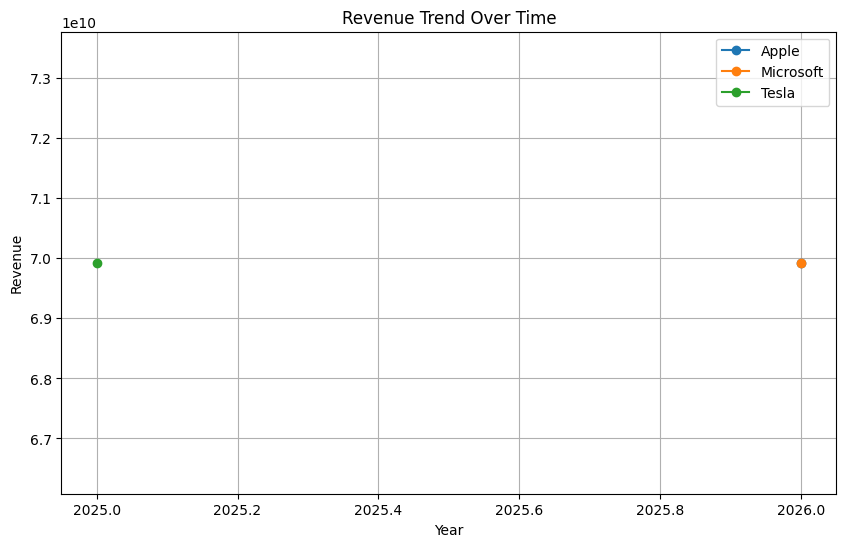

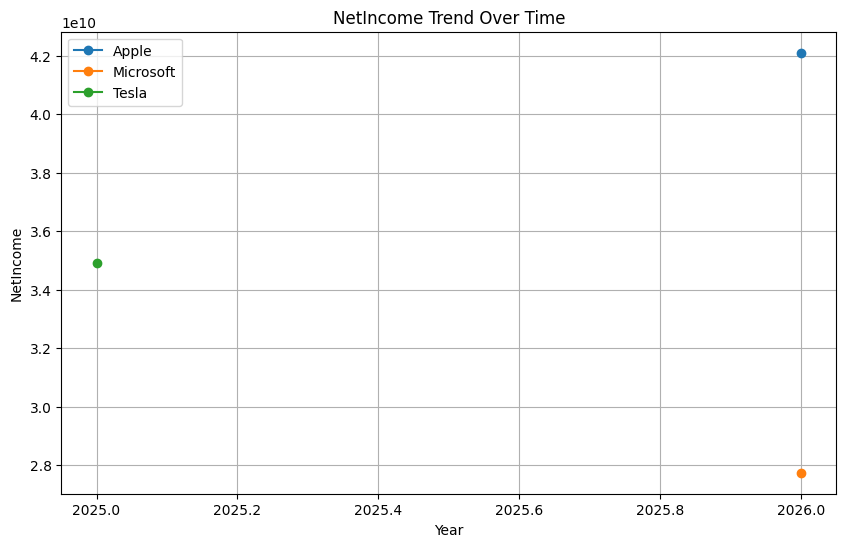

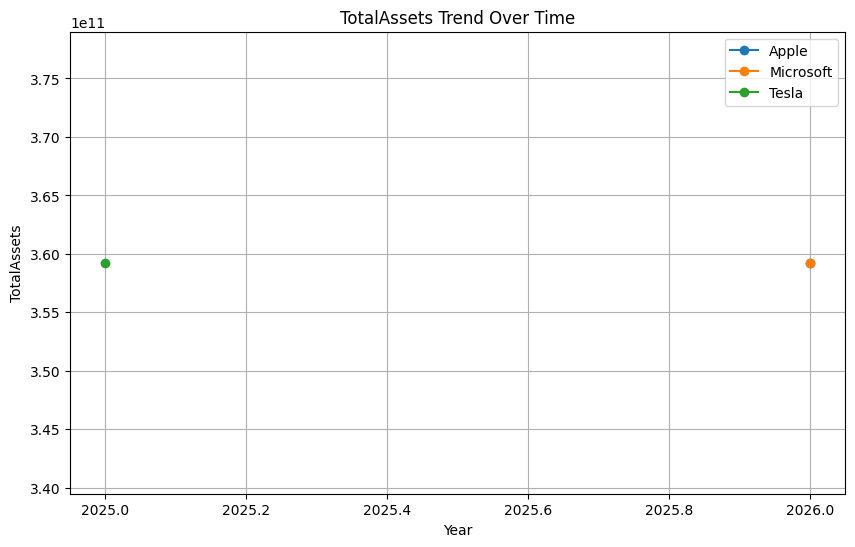

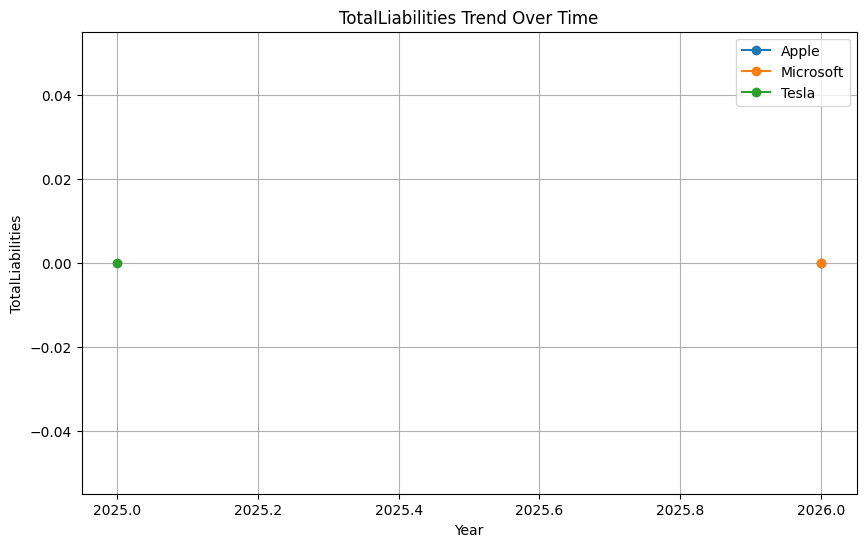

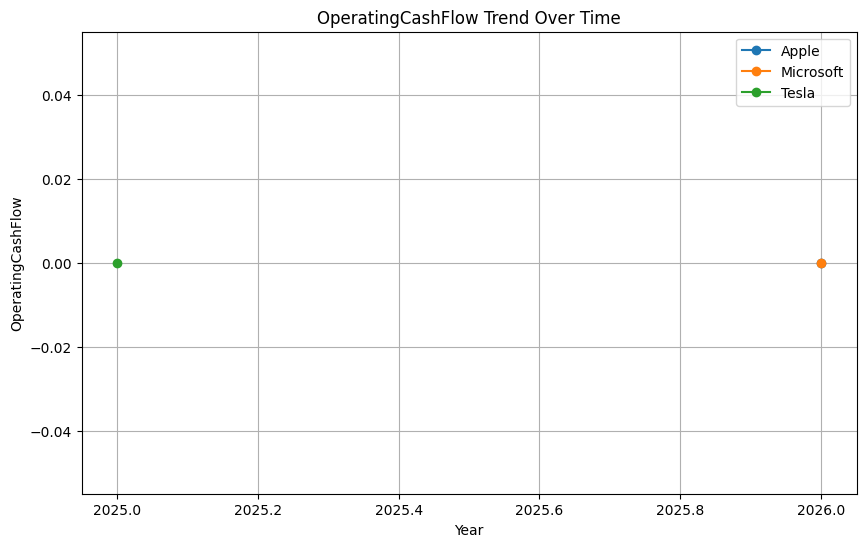

In [97]:
## Trend analysis
import matplotlib.pyplot as plt
for metric in metrics:  
    plt.figure(figsize=(10,6))
    for company in companies.keys():
        company_data = df[df['Company'] == company]
        plt.plot(company_data['Year'], company_data[metric], marker='o', label=company)
    plt.title(f'{metric} Trend Over Time')
    plt.xlabel('Year')
    plt.ylabel(metric)
    plt.legend()
    plt.grid()
    plt.show()

## Conclusion
This notebook analyzes financial performance and YoY growth trends.